   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.6 MB/s eta 0:00:00


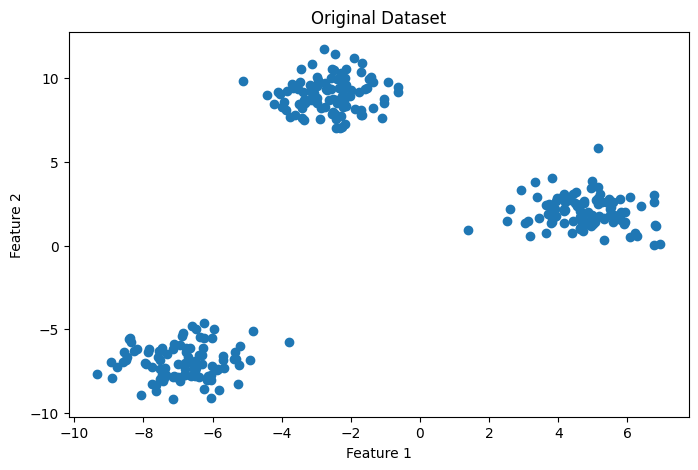

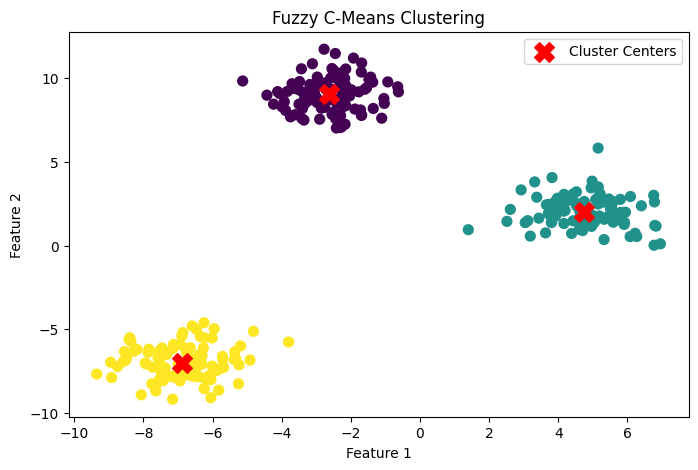

Membership Values (First 5 Data Points):
[[0.00242898 0.00270294 0.95902063 0.01443034 0.01457496]
 [0.00305838 0.00326098 0.03139287 0.98019355 0.01669062]
 [0.99451264 0.99403608 0.0095865  0.00537611 0.96873443]]

Evaluation Results
-------------------------
Number of Clusters: 3
Fuzziness Parameter: 2.0
Silhouette Score: 0.8480303059596955
Fuzzy Partition Coefficient: 0.9579230857438216
Number of Iterations: 10
Cluster 0: 100 data points
Cluster 1: 100 data points
Cluster 2: 100 data points


In [5]:
# ==========================================
# Experiment 4: Fuzzy C-Means Clustering
# ==========================================

# 1. Import required libraries
import numpy as np
import matplotlib.pyplot as plt
!pip install scikit-fuzzy

import skfuzzy as fuzz

from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score


# 2. Generate synthetic dataset
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)


# 3. Visualize original dataset
plt.figure(figsize=(8, 5))

plt.scatter(X[:, 0], X[:, 1])

plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# ==========================================
# 4. Set FCM Parameters
# ==========================================

c = 3
m = 2.0


# 5. Convert data into required format
# FCM expects features x samples
data = X.T


# ==========================================
# 6. Apply Fuzzy C-Means
# ==========================================

centers, membership, initial_membership, \
distance, objective, iterations, fpc = fuzz.cluster.cmeans(
    data,
    c=c,
    m=m,
    error=0.005,
    maxiter=1000,
    init=None,
    seed=42
)


# ==========================================
# 7. Get Cluster Labels
# ==========================================

# Assign each point to the cluster
# with the highest membership value

labels = np.argmax(membership, axis=0)


# ==========================================
# 8. Visualize Final Clusters
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis',
    s=50
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200,
    color='red',
    label='Cluster Centers'
)

plt.title("Fuzzy C-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


# ==========================================
# 9. Display Membership Values
# ==========================================

print("Membership Values (First 5 Data Points):")
print(membership[:, :5])


# ==========================================
# 10. Evaluation
# ==========================================

silhouette = silhouette_score(X, labels)

print("\nEvaluation Results")
print("-------------------------")
print("Number of Clusters:", c)
print("Fuzziness Parameter:", m)
print("Silhouette Score:", silhouette)
print("Fuzzy Partition Coefficient:", fpc)
print("Number of Iterations:", iterations)


# ==========================================
# 11. Display Cluster Information
# ==========================================

for i in range(c):
    print(
        f"Cluster {i}: {np.sum(labels == i)} data points"
    )